In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons
import warnings
warnings.filterwarnings("ignore")

## import csv data as dataframe


In [4]:
df = pd.read_csv(r"D:\KrishNaik\E_to_E_MLProject\notebook\data\StudentsPerformance.csv")


In [5]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [6]:
df.shape

(1000, 8)

## data check to perform
    check Missing values
    check duplicates
    check data types
    check sdtatics of unique values of each column
    checks statics of data set
    check various categories present in the different categorical columns

### check misssing values


In [7]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

# check duplicates

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
# check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [10]:
# checking the number of unique values of eah columns

df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [11]:
## check statics of data set
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


# Exploring Data

In [12]:
print("Categories in 'gender' variable: ",end=" ")
print(df['gender'].unique())


print("Categories in 'race/ethnicity' variable: ",end=" ")
print(df['race/ethnicity'].unique())

print("Categories in 'parental level of education' variable: ",end=" ")
print(df['parental level of education'].unique())

print("Categories in 'lunch' variable: ",end=" ")
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable: ",end=" ")
print(df['test preparation course'].unique())

Categories in 'gender' variable:  ['female' 'male']
Categories in 'race/ethnicity' variable:  ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in 'parental level of education' variable:  ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable:  ['standard' 'free/reduced']
Categories in 'test preparation course' variable:  ['none' 'completed']


In [13]:
# define numerical and cetegorical feature

numerical_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_feature  = [feature for feature in df.columns if df[feature].dtype == 'O']

# print numerical and categorical features
print(' we have {} numerical features : {}'.format(len(numerical_features),numerical_features))
print(' we have {} categorical features : {}'.format(len(categorical_feature),categorical_feature))

 we have 3 numerical features : ['math score', 'reading score', 'writing score']
 we have 5 categorical features : ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


# adding columns for total score and average score

In [14]:
df['total score'] = df['math score'] + df['reading score'] + df['writing score']
df['average score'] = df['total score'] / 3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [15]:
reading_full = df[df['reading score'] == 100] ['average score'].count()
writing_full = df[df['writing score'] == 100] ['average score'].count()
math_full = df[df['math score'] == 100] ['average score'].count()

print("Number of students who scored full marks in reading : ",reading_full)
print("Number of students who scored full marks in writing : ",writing_full)
print("Number of students who scored full marks in math : ",math_full)


Number of students who scored full marks in reading :  17
Number of students who scored full marks in writing :  14
Number of students who scored full marks in math :  7


In [16]:
reading_less_20 = df[df['reading score'] < 20] ['average score'].count()
writing_less_20 = df[df['writing score'] < 20] ['average score'].count()
math_less_20 = df[df['math score'] < 20] ['average score'].count()

print("Number of students who scored less than 20 marks in reading : ",reading_less_20)
print("Number of students who scored less than 20 marks in writing : ",writing_less_20)
print("Number of students who scored less than 20 marks in math : ",math_less_20)

Number of students who scored less than 20 marks in reading :  1
Number of students who scored less than 20 marks in writing :  3
Number of students who scored less than 20 marks in math :  4


# Histograme


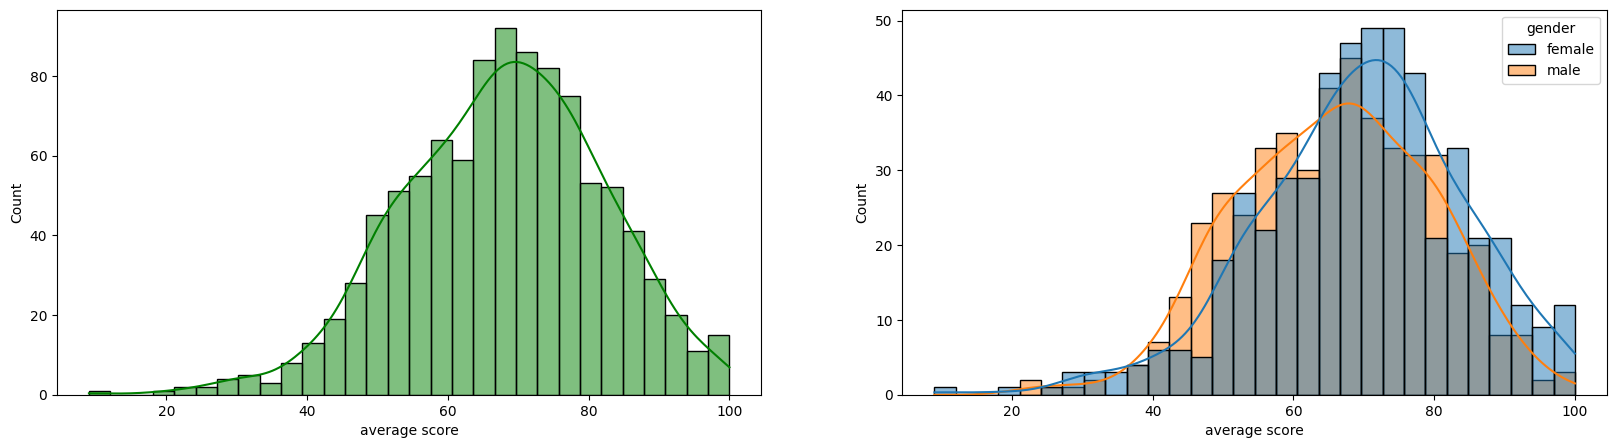

In [19]:
fig,axs = plt.subplots(1,2,figsize=(20,5))

plt.subplot(121)
sns.histplot(data=df,x='average score',bins=30,kde=True,color='g')

plt.subplot(122)
sns.histplot(data=df,x='average score',bins=30,kde=True,hue='gender')

plt.show()

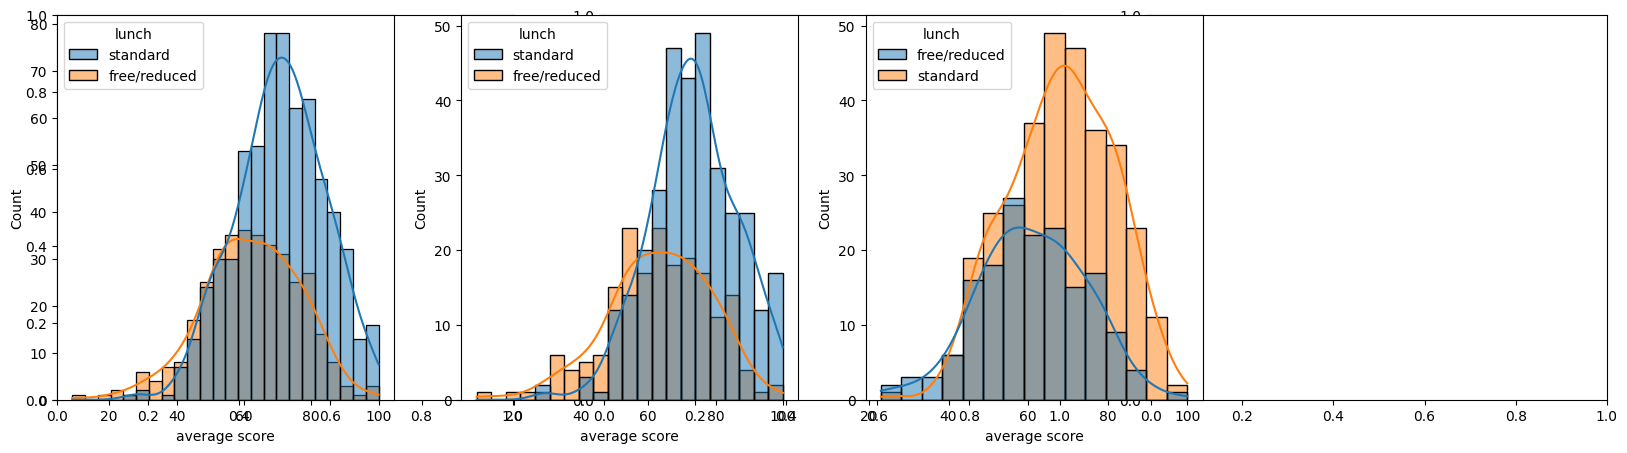

In [23]:
plt.subplots(1,3,figsize=(20,5))

plt.subplot(141)
sns.histplot(data=df,x = 'average score',kde= True,hue = 'lunch')

plt.subplot(142)
sns.histplot(data=df[df.gender == 'female'],x = 'average score',kde= True,hue = 'lunch')

plt.subplot(143)
sns.histplot(data=df[df.gender == 'male'],x = 'average score',kde= True,hue = 'lunch')

plt.show()
